# CAS NLP Module 4 - Finetuning LLMs for fairy telling
**Ana Stojiljkovic & Michael Horn**

--- 

### **Goal**

Let's talk about narrative quality

In [15]:
from gtts import gTTS
from IPython.display import Audio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set(style="whitegrid", palette="muted", font_scale=1.2)

In [20]:
gpt_large_base_model = "Once upon a time there was a fairy tale: A young girl went to the fair to buy her mother a flower for her birthday, but the girl's mother told her that the flower was a rose. When the girl grew up, she told her mother it was a rose, and she didn't want the money, so her mother told the fairy tale about the rose, and it became the fairy tale about the fairy tale! (This was before the Internet!)"
gpt_large_33310_model = "Once upon a time there was a fairy, who had six daughters by her, and she thought of them all day as if they were her own. One day, when the Queen, thinking that she was going to a palace, and was about to pick some one of the finest fruit, met with the mules, he said: “Why not take a mules?”; and he replied, “Oh no! why not, but I will do it; you know quite well,”--’s just the truth to let me know, he; and went on. So she went and came up to the palace, got into the tower, and asked if it was good, and leaned on top of an old tower, old, old; butting. Nowas, and Morraha, who was, the dumb, the bulling for her own, while she was, such as he was, as he held his own, as if he was going out to pick one day."

In [21]:
tts_gpt_base = gTTS(gpt_large_base_model, lang='en')
tts_gpt_base.save("fairy_tale_gpt_large_base.mp3")

tts_gpt_epoch2 = gTTS(gpt_large_33310_model, lang="en")
tts_gpt_epoch2.save("fairy_tale_gpt_large_epoch2.mp3")

In [3]:
Audio("audios/fairy_tale_gpt_large_base.mp3")

In [36]:
Audio("audios/fairy_tale_gpt_large_epoch2.mp3")

### **Problem**

Preliminary experiments indicate that narrative coherence deteriorates after fine-tuning language models on a domain-specific fairy-tale corpus, despite improvements in stylistic alignment.

---

### **Hypotheses**

1. **Model capacity limitation**  
   The observed loss of coherence may be partly due to insufficient model capacity, with smaller models being less able to retain global narrative structure during fine-tuning.  
   → *This hypothesis is investigated by fine-tuning a larger pretrained model (Apertus 8B).*

2. **Over-specialization due to full-parameter fine-tuning**  
   Fine-tuning all model parameters may encourage excessive stylistic specialization, leading to degradation in narrative coherence and general fluency.  
   → *This hypothesis is investigated by applying parameter-efficient fine-tuning using the LoRA technique on Apertus 8B.*

3. **Dataset size constraints**  
   The size of the fine-tuning dataset may be insufficient to support stable adaptation of large language models to a narrow narrative domain without loss of coherence.  
   → *Systematically testing this hypothesis would require larger or multiple datasets and is therefore considered out of scope for this project; it is discussed in light of the observed results and existing literature.*



In [12]:
# Folder containing all experiment CSVs
DATA_DIR = Path("data_experiments")

dfs = []

model_order = ["gpt2_small", "gpt2_medium", "gpt2_large", "gpt2_xl", "apertus_8B"]
checkpoint_order = ["base", "16655", "33310", "49965", "66620", "83275"]

# Mapping for epoch names to checkpoint names
epoch_mapping = {
    "base": "base",
    "epoch1": "16655",
    "epoch2": "33310",
    "epoch3": "49965",
    "epoch4": "66620",
    "epoch5": "83275"
}

for csv_file in DATA_DIR.glob("*.csv"):
    # Extract model name from filename
    model_name = csv_file.stem

    df_tmp = pd.read_csv(csv_file, sep=None, engine="python")

    # Ensure checkpoint is a column (not index)
    if "checkpoint" not in df_tmp.columns:
        df_tmp = df_tmp.reset_index().rename(columns={"index": "checkpoint"})

    # Rename epoch-based checkpoints to match standard naming
    df_tmp["checkpoint"] = df_tmp["checkpoint"].astype(str).replace(epoch_mapping)

    # Add model column
    df_tmp["model"] = model_name

    dfs.append(df_tmp)

# Concatenate all experiments into one DataFrame
df = pd.concat(dfs, ignore_index=True)

# Enforce categorical ordering
df["model"] = pd.Categorical(
    df["model"],
    categories=model_order,
    ordered=True
)

df["checkpoint"] = pd.Categorical(
    df["checkpoint"].astype(str),
    categories=checkpoint_order,
    ordered=True
)

# Final sorting
df = df.sort_values(["model", "checkpoint"]).reset_index(drop=True)

In [13]:
df

,checkpoint,self_bleu_mean,self_bleu_std,distinct_2_mean,distinct_2_std,surprisal_mean,surprisal_std,fairy_word_mean,fairy_word_std,fairy_classifier_mean,fairy_classifier_std,model
0,base,0.487176,0.055596,0.844117,0.089136,2.151696,0.226034,3.533333,1.477235,0.565421,0.182659,gpt2_small
1,16655,0.646918,0.061039,0.818318,0.053036,2.519049,0.205091,2.833333,1.185561,0.866537,0.050683,gpt2_small
2,33310,0.661555,0.065521,0.833243,0.077689,2.601722,0.211908,3.566667,1.542365,0.841943,0.045400,gpt2_small
3,49965,0.638971,0.048203,0.822168,0.074301,2.454386,0.181512,3.566667,1.358512,0.854793,0.050334,gpt2_small
4,66620,0.636648,0.066877,0.775687,0.103671,2.420210,0.270555,2.800000,1.166190,0.871226,0.057990,gpt2_small
5,83275,0.649570,0.045245,0.776948,0.091836,2.371783,0.218567,2.866667,1.203698,0.855837,0.057275,gpt2_small
6,base,0.446734,0.072058,0.901917,0.044843,1.995990,0.184080,3.633333,1.401983,0.667875,0.179465,gpt2_medium
7,16655,0.629300,0.064278,0.868230,0.051682,2.572863,0.171840,2.866667,1.087300,0.859495,0.054878,gpt2_medium
8,33310,0.625002,0.049951,0.887423,0.036793,2.584517,0.184789,3.166667,1.368292,0.856550,0.037797,gpt2_medium
9,49965,0.581431,0.057687,0.881372,0.054860,2.501643,0.223654,3.266667,1.263153,0.877230,0.046051,gpt2_medium


## Self-blue

Self-BLEU quantifies how similar the generated samples are to each other.  
  - High Self-BLEU  → low diversity (many similar generations)
  - Low Self-BLEU   → high diversity (more varied generations)

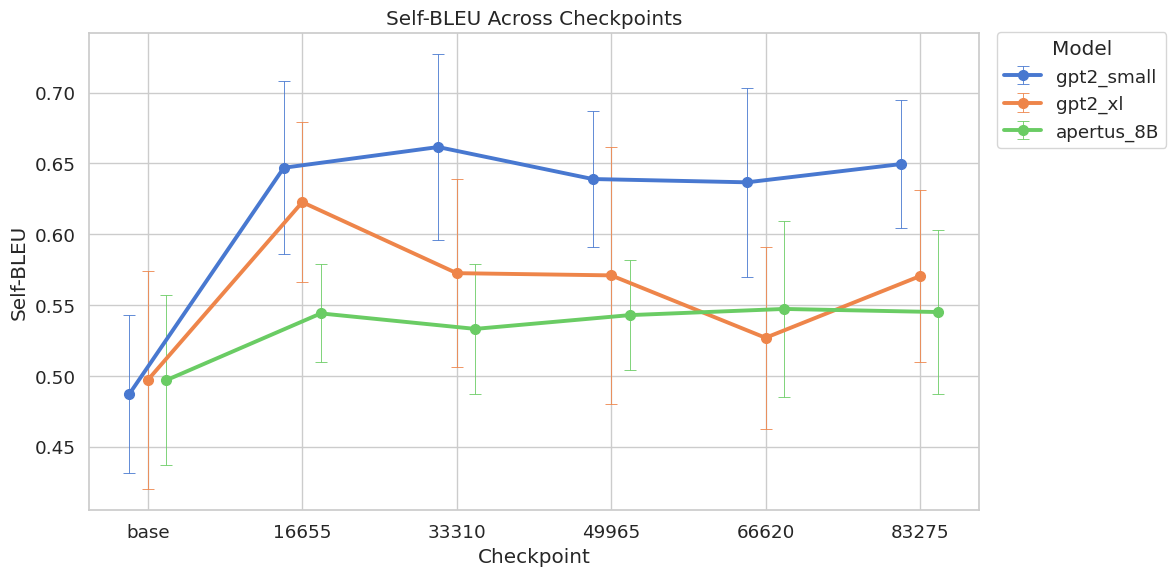

In [21]:
plt.figure(figsize=(12,6))

checkpoints = ["base","16655","33310","49965","66620","83275"]
x_base = np.arange(len(checkpoints))

# Filter to show only specific models
models_to_show = ["gpt2_small", "gpt2_xl", "apertus_8B"]
models = [m for m in df["model"].unique() if m in models_to_show]
offset = 0.12

# Visual emphasis settings
style = {
    "gpt2_small":  {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "gpt2_xl":     {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "apertus_8B":  {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
}

for i, model in enumerate(models):
    subset = (
        df[df["model"] == model]
        .set_index("checkpoint")
        .loc[checkpoints]
        .reset_index()
    )

    # Horizontal offset so models don’t overlap
    x = x_base + (i - (len(models) - 1) / 2) * offset

    plt.errorbar(
        x,
        subset["self_bleu_mean"],
        yerr=subset["self_bleu_std"],
        marker="o",
        capsize=4,
        elinewidth=0.6,
        capthick=0.6,
        label=model,
        alpha=style[model]["alpha"],
        linewidth=style[model]["lw"],
        markersize=style[model]["ms"],
        zorder=style[model]["z"]
    )

plt.title("Self-BLEU Across Checkpoints")
plt.ylabel("Self-BLEU")
plt.xlabel("Checkpoint")
plt.xticks(x_base, checkpoints)

plt.legend(title="Model", loc="upper left", bbox_to_anchor=(1.01, 1.02))
plt.tight_layout()
#plt.savefig("self_bleu.png", dpi=300, bbox_inches="tight")
plt.show()

## Lexical diversity

Distinct-2 measures the proportion of unique bigrams.

  - Higher Distinct-2 → more diverse and less repetitive text
  - Lower Distinct-2  → more repetition

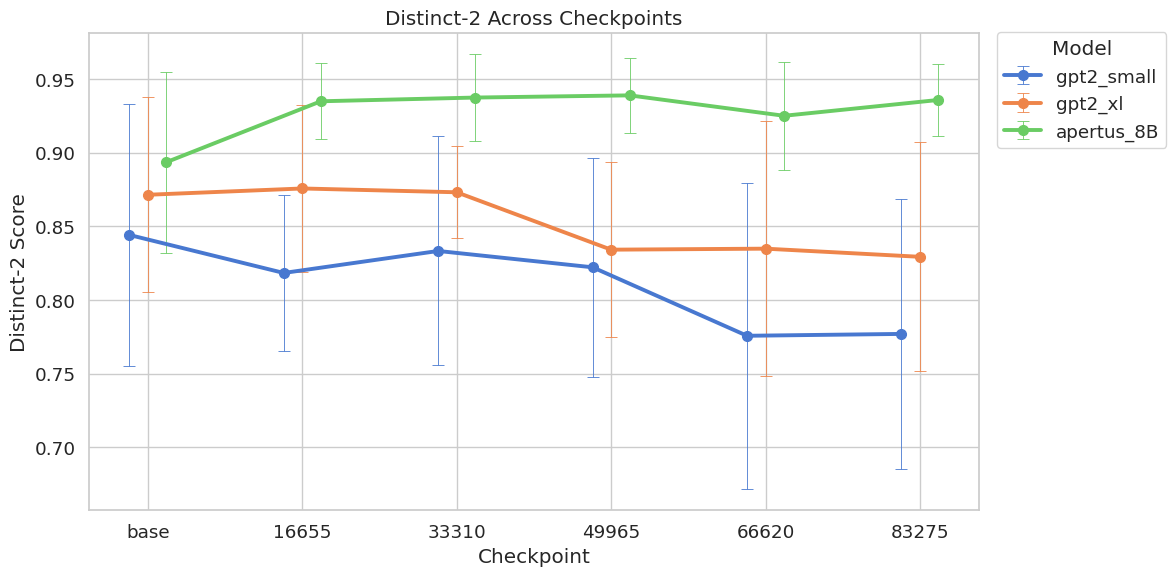

In [27]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

checkpoints = ["base","16655","33310","49965","66620","83275"]
x_base = np.arange(len(checkpoints))

# Filter to show only specific models
models_to_show = ["gpt2_small", "gpt2_xl", "apertus_8B"]
models = [m for m in df["model"].unique() if m in models_to_show]
offset = 0.12

style = {
    "gpt2_small":  {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "gpt2_xl":     {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "apertus_8B":  {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
}

for i, model in enumerate(models):
    subset = (
        df[df["model"] == model]
        .set_index("checkpoint")
        .loc[checkpoints]
        .reset_index()
    )

    # Horizontal offset so models don’t overlap
    x = x_base + (i - (len(models) - 1) / 2) * offset

    plt.errorbar(
        x,
        subset["distinct_2_mean"],
        yerr=subset["distinct_2_std"],
        marker="o",
        capsize=4,
        elinewidth=0.6,     # thin error bars
        capthick=0.6,
        label=model,
        alpha=style[model]["alpha"],
        linewidth=style[model]["lw"],
        markersize=style[model]["ms"],
        zorder=style[model]["z"]
    )

plt.title("Distinct-2 Across Checkpoints")
plt.ylabel("Distinct-2 Score")
plt.xlabel("Checkpoint")
plt.xticks(x_base, checkpoints)

plt.legend(title="Model", loc="upper left", bbox_to_anchor=(1.01, 1.02))
plt.tight_layout()
#plt.savefig("lexical_diversity.png", dpi=300, bbox_inches="tight")

plt.show()

## Suprisal (under the base model)

Surprisal measures how unexpected a text is to the base (non-finetuned) model:  
  - Lower surprisal → text is more likely / more familiar to the model (claoser to base distribution)
  - Higher surprisal → text is more unexpected (stronger domain shift)

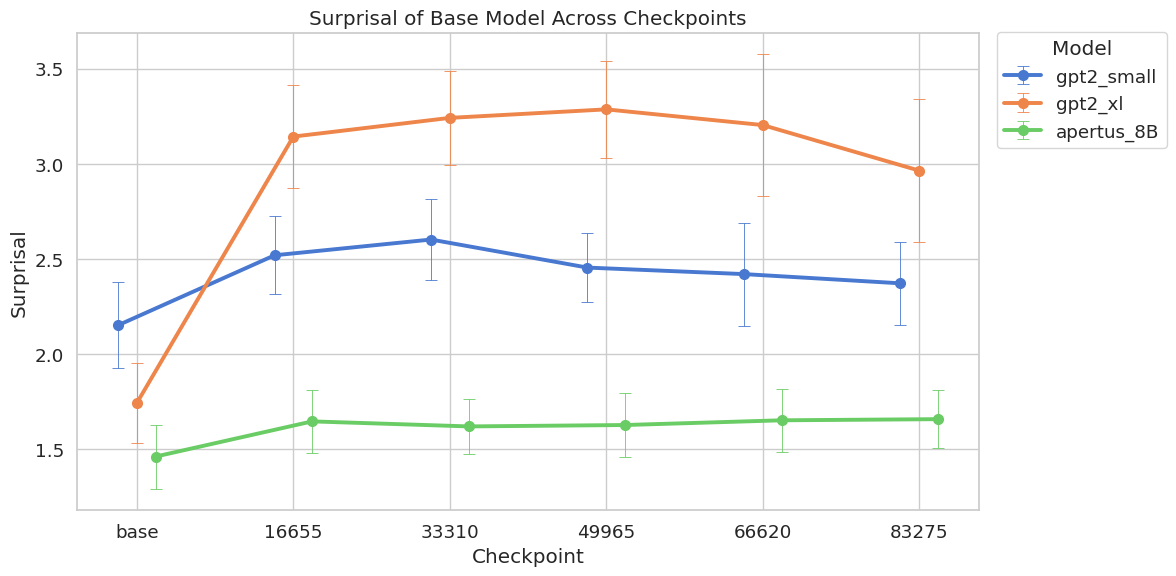

In [32]:
plt.figure(figsize=(12,6))

checkpoints = ["base","16655","33310","49965","66620","83275"]
x_base = np.arange(len(checkpoints))

# Filter to show only specific models
models_to_show = ["gpt2_small", "gpt2_xl", "apertus_8B"]
models = [m for m in df["model"].unique() if m in models_to_show]
offset = 0.12

style = {
    "gpt2_small":  {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "gpt2_xl":     {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "apertus_8B":  {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
}

for i, model in enumerate(models):
    subset = (
        df[df["model"] == model]
        .set_index("checkpoint")
        .loc[checkpoints]
        .reset_index()
    )

    # Horizontal offset so models don't overlap
    x = x_base + (i - (len(models) - 1) / 2) * offset

    plt.errorbar(
        x,
        subset["surprisal_mean"],
        yerr=subset["surprisal_std"],
        marker="o",
        capsize=4,
        elinewidth=0.6,   # thin error bars
        capthick=0.6,
        label=model,
        alpha=style[model]["alpha"],
        linewidth=style[model]["lw"],
        markersize=style[model]["ms"],
        zorder=style[model]["z"]
    )

plt.title("Surprisal of Base Model Across Checkpoints")
plt.ylabel("Surprisal")
plt.xlabel("Checkpoint")
plt.xticks(x_base, checkpoints)

plt.legend(title="Model", loc="upper left", bbox_to_anchor=(1.01, 1.02))
plt.tight_layout()
#plt.savefig("surprisal.png", dpi=300, bbox_inches="tight")
plt.show()

## Fairy words score
Higher scores indicate more fairy-tale–like content. 

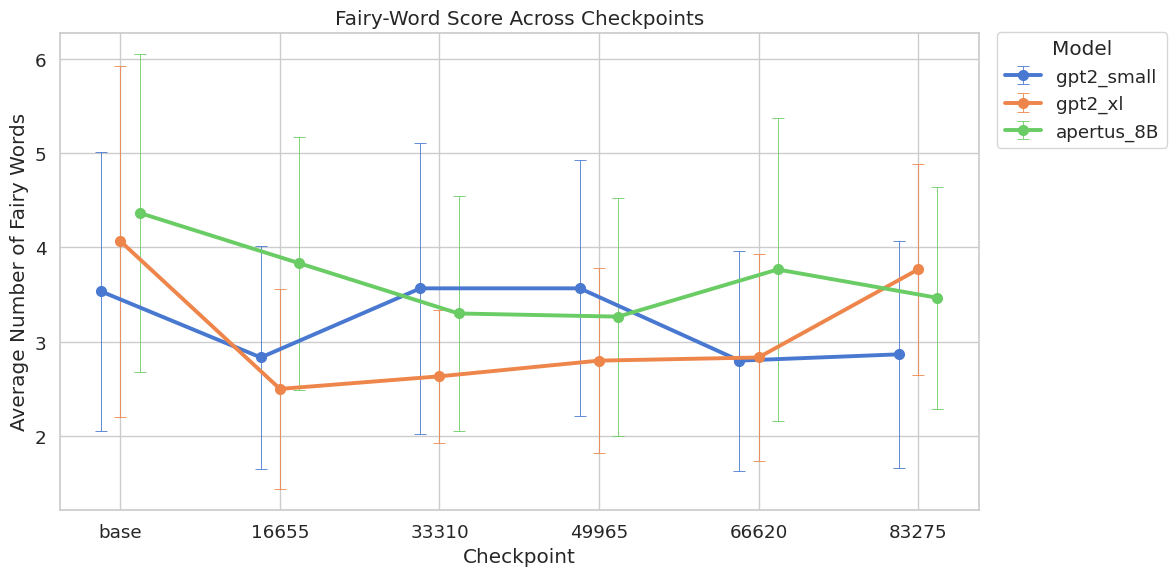

In [34]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

checkpoints = ["base","16655","33310","49965","66620","83275"]
x_base = np.arange(len(checkpoints))

# Filter to show only specific models
models_to_show = ["gpt2_small", "gpt2_xl", "apertus_8B"]
models = [m for m in df["model"].unique() if m in models_to_show]
offset = 0.12

# Style settings to emphasize small and XL
style = {
    "gpt2_small":  {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "gpt2_xl":     {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "apertus_8B":  {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
}

for i, model in enumerate(models):
    subset = (
        df[df["model"] == model]
        .set_index("checkpoint")
        .loc[checkpoints]
        .reset_index()
    )

    # Horizontal offset so models don't overlap
    x = x_base + (i - (len(models) - 1) / 2) * offset

    plt.errorbar(
        x,
        subset["fairy_word_mean"],
        yerr=subset["fairy_word_std"],
        marker="o",
        capsize=4,
        elinewidth=0.6,
        capthick=0.6,
        label=model,
        alpha=style[model]["alpha"],
        linewidth=style[model]["lw"],
        markersize=style[model]["ms"],
        zorder=style[model]["z"]
    )

plt.title("Fairy-Word Score Across Checkpoints")
plt.ylabel("Average Number of Fairy Words")
plt.xlabel("Checkpoint")
plt.xticks(x_base, checkpoints)

plt.legend(title="Model", loc="upper left", bbox_to_anchor=(1.01, 1.02))
plt.tight_layout()
#plt.savefig("fairy_word_score.png", dpi=300, bbox_inches="tight")
plt.show()

## Fairy classifier
Zero-shot classification with the BART model.

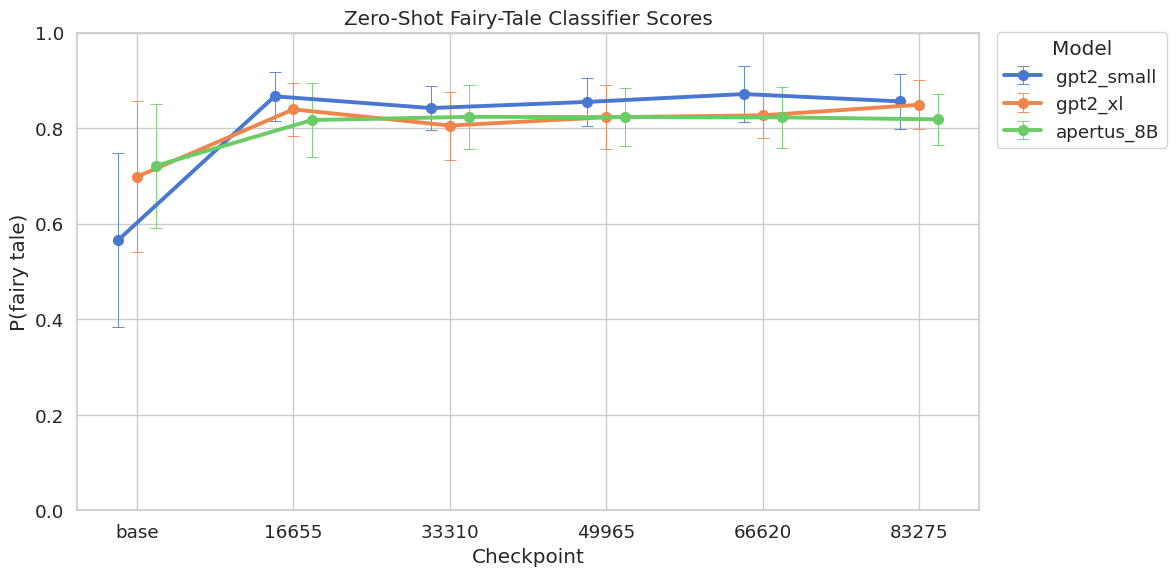

In [35]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

checkpoints = ["base","16655","33310","49965","66620","83275"]
x_base = np.arange(len(checkpoints))

# Filter to show only specific models
models_to_show = ["gpt2_small", "gpt2_xl", "apertus_8B"]
models = [m for m in df["model"].unique() if m in models_to_show]
offset = 0.12

# Visual emphasis settings
style = {
    "gpt2_small":  {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "gpt2_xl":     {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "apertus_8B":  {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
}

for i, model in enumerate(models):
    subset = (
        df[df["model"] == model]
        .set_index("checkpoint")
        .loc[checkpoints]
        .reset_index()
    )

    x = x_base + (i - (len(models)-1)/2) * offset

    plt.errorbar(
        x,
        subset["fairy_classifier_mean"],
        yerr=subset["fairy_classifier_std"],
        marker="o",
        capsize=4,
        elinewidth=0.6,
        capthick=0.6,
        label=model,
        alpha=style[model]["alpha"],
        linewidth=style[model]["lw"],
        markersize=style[model]["ms"],
        zorder=style[model]["z"]
    )

plt.title("Zero-Shot Fairy-Tale Classifier Scores")
plt.ylabel("P(fairy tale)")
plt.xlabel("Checkpoint")
plt.xticks(x_base, checkpoints)
plt.ylim(0, 1)

plt.legend(title="Model", loc="upper left", bbox_to_anchor=(1.01, 1.02))
plt.tight_layout()
#plt.savefig("fairy_tale_classifier.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
## Narrative coeherence

In [38]:
apertus_base_model = "Once upon a time there was a fairy who lived in a cloud. She was so light that she could fly with the wildest wind; and the wind made her clothes of cloud so thin that a breath would blow them away. But she was a powerful fairy, who could make the wind blow a hundred times stronger, if she chose. She could make rain and hail, or snow and sleet; and she could send the lightning and thunder too. Besides all this, she could change herself into whatever form she liked. For instance, she could change herself into a beautiful girl or a very ugly one. You would never know which it was, if she did not choose to tell you. Sometimes she would make herself very tall and very slender, with long hair and eyes like fire; but at other times she would look like an old woman with gray hair and wrinkles, and eyes which were dull and weak like the eyes of an owl. She was very..."
apertus_epoch1_model = "Once upon a time there was a fairy named Paribanou, who was the wife of the Sultan, and mother of the Princess Badoura. As the Sultan was one day playing a game of chess in the palace courtyard with a stranger, who was a good chess-player, the stranger saw the Princess Badoura, who was very lovely, and was struck with her beauty, and he took up his chessmen, and turned away. The Sultan’s wife saw this, and said to her husband: “My Lord, what is the reason that the stranger, who was playing with you, went away without bidding me farewell, as was the custom of the country?” “He went away,” said the Sultan, “because he was afraid of losing the game.” “It was not that,” said the stranger, “for I had not played ten moves with him before I saw in the next room a Princess so lovely, that I should be very unhappy if I had not the good fortune to see her face.” The Sultan, who was a"

In [39]:
tts_apertus_base = gTTS(apertus_base_model, lang='en')
tts_apertus_base.save("fairy_tale_apertus_base.mp3")

tts_apertus_epoch1 = gTTS(apertus_epoch1_model, lang="en")
tts_apertus_epoch1.save("fairy_tale_apertus_epoch1.mp3")

In [41]:
Audio("audios/fairy_tale_apertus_base.mp3")

In [43]:
Audio("audios/fairy_tale_apertus_epoch1.mp3")

# Conclusion
 - Fine-tuning GPT-2 small strongly increased fairy-tale style but substantially reduced narrative coherence and fluency.
 - GPT-2 XL showed greater stability than GPT-2 small, with less extreme repetition after fine-tuning.
 - Apertus 8B exhibited the most stable behavior, combining strong stylistic adaptation with relatively low surprisal and high lexical diversity.

These results indicate that larger models are more resilient to domain-specific fine-tuning.
Model scale therefore plays a key role in balancing stylistic specialization and narrative coherence.